# Introducción de datos

Notebook introductorio: qué archivos hay, dimensiones aproximadas y un vistazo rápido a pedidos e items.

El TFM plantea un agente conversacional integrado con modelos predictivos, CBR y explicabilidad sobre una plataforma de pedidos con entrega a domicilio. Aquí solo se documenta el material con el que se trabaja.

**Objetivos con los datos:** demanda por producto, ingresos por periodo y análisis de productos con más ventas.

**Origen:** exportaciones CSV del cliente *triplekb* en Faster Order (pedidos, líneas de pedido, clientes y métricas agregadas).


## Archivos CSV

Cuatro ficheros en `data/`:

**`orders.csv`** — Un registro por pedido: identificadores, fecha y hora, sucursal, estado, pago, totales, número de líneas (`item_count`), tipo de entrega y zona.

**`order-items.csv`** — Una fila por línea de pedido: producto, categoría, precio, cantidad, subtotal y campos de extras o comentario.

**`customers.csv`** — Resumen por cliente (teléfono como id): totales de pedidos y gasto, fechas del primer y último pedido, preferencias de pago y sucursal.

**`customer-metrics.csv`** — Mismo universo de clientes con métricas más detalladas (frecuencia, día u hora favoritos, categoría o producto favorito, ratio delivery/pickup, actividad reciente, score de churn, etc.).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

DATA_DIR = Path('data')

## Carga

Los CSV se leen desde `../data`.


In [ ]:
orders_df = pd.read_csv(DATA_DIR / 'orders.csv')
order_items_df = pd.read_csv(DATA_DIR / 'order-items.csv')
customers_df = pd.read_csv(DATA_DIR / 'customers.csv')
customer_behavior_df = pd.read_csv(DATA_DIR / 'customer-metrics.csv')

## Resúmenes numéricos

### Pedidos (`orders.csv`)


In [ ]:
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

display(
    pd.DataFrame(
        {
            'filas': [len(orders_df)],
            'columnas': [orders_df.shape[1]],
            'fecha_min': [orders_df['order_date'].min()],
            'fecha_max': [orders_df['order_date'].max()],
        }
    )
)
display(orders_df[['subtotal', 'total', 'item_count']].describe().T)
display(orders_df['status'].value_counts().to_frame('n'))
display(orders_df['payment_method'].value_counts().head(10).to_frame('n'))
display(orders_df['delivery_type'].value_counts().to_frame('n'))

,filas,columnas,fecha_min,fecha_max
0,17582,25,2025-06-23,2026-03-08


,count,mean,std,min,25%,50%,75%,max
subtotal,17582.0,16.966686,11.807198,1.5,9.4,14.48,20.80,235.9
total,17582.0,18.980536,12.053106,1.5,11.4,16.48,22.97,239.9
item_count,17582.0,2.444034,1.232544,1.0,2.0,2.00,3.00,12.0


,n
status,
pending,17219
ready,270
delivered,88
cancelled,3
confirmed,1
preparing,1


,n
payment_method,
Pago móvil,8202
pago móvil,6721
Efectivo,882
efectivo,792
Zelle,368
zelle,305
Pago Movil,212
Binance,59
binance,41


,n
delivery_type,
delivery,15539
pickup,2043


### Líneas de pedido (`order-items.csv`)


In [ ]:
display(
    pd.DataFrame(
        {
            'filas': [len(order_items_df)],
            'columnas': [order_items_df.shape[1]],
            'productos_distintos': [order_items_df['product_id'].nunique()],
            'categorias_distintas': [order_items_df['category_name'].nunique()],
        }
    )
)
display(order_items_df['category_name'].value_counts().head(10).to_frame('n'))
display(order_items_df[['product_price', 'quantity']].describe().T)
display(
    pd.DataFrame(
        {
            'lineas_con_extras': [order_items_df['has_extras'].sum()],
            'pct': [order_items_df['has_extras'].mean() * 100],
        }
    )
)

,filas,columnas,productos_distintos,categorias_distintas
0,42971,20,45,6


,n
category_name,
Hamburguesas,26660
Papas,8013
Bebidas,3672
Pepitos,2285
Entradas,1360
Perros calientes,981


,count,mean,std,min,25%,50%,75%,max
product_price,42971.0,5.011110,2.596485,1.5,2.5,4.9,6.9,13.99
quantity,42971.0,1.466314,1.174669,1.0,1.0,1.0,2.0,50.00


,lineas_con_extras,pct
0,6265,14.5796


### Clientes (`customers.csv`)


In [ ]:
customers_df['first_order_date'] = pd.to_datetime(customers_df['first_order_date'])
customers_df['last_order_date'] = pd.to_datetime(customers_df['last_order_date'])
display(
    pd.DataFrame(
        {
            'filas': [len(customers_df)],
            'columnas': [customers_df.shape[1]],
            'clientes_distintos': [customers_df['customer_id'].nunique()],
        }
    )
)
display(customers_df[['total_orders', 'total_spent']].describe().T)
display(
    pd.DataFrame(
        {
            'first_min': [customers_df['first_order_date'].min()],
            'last_max': [customers_df['last_order_date'].max()],
        }
    )
)
display(customers_df['delivery_type'].value_counts().to_frame('n'))

,filas,columnas,clientes_distintos
0,7595,17,7595


,count,mean,std,min,25%,50%,75%,max
total_orders,7595.0,2.314944,3.172602,1.0,1.00,1.00,2.0,90.0
total_spent,7595.0,43.938878,62.105334,3.5,14.97,24.49,47.4,1589.0


,first_min,last_max
0,2025-06-23,2026-03-08


,n
delivery_type,
delivery,6611
pickup,984


### Métricas de comportamiento (`customer-metrics.csv`)


In [ ]:
display(
    pd.DataFrame(
        {
            'filas': [len(customer_behavior_df)],
            'columnas': [customer_behavior_df.shape[1]],
            'telefonos_distintos': [customer_behavior_df['customer_phone'].nunique()],
        }
    )
)
display(customer_behavior_df[['orders_per_month', 'orders_per_week', 'favorite_hour', 'churn_risk_score']].describe().T)
display(customer_behavior_df['is_active_customer'].value_counts().to_frame('n'))

,filas,columnas,telefonos_distintos
0,7595,24,7595


,count,mean,std,min,25%,50%,75%,max
orders_per_month,7595.0,1.463255,6.033208,0.0,0.0,0.0,1.12,120.0
orders_per_week,7595.0,0.341505,1.407785,0.0,0.0,0.0,0.26,28.0
favorite_hour,7595.0,9.859381,10.320961,0.0,0.0,2.0,22.00,23.0
churn_risk_score,7595.0,2.335558,13.432216,0.0,0.0,0.0,0.64,513.0


,n
is_active_customer,
False,5759
True,1836


## Gráficos

Serie diaria de pedidos, distribución por día de la semana y por hora, e histograma del total del pedido. Al ejecutar la celda se guarda `distribucion_pedidos.png` en el directorio de trabajo del notebook.


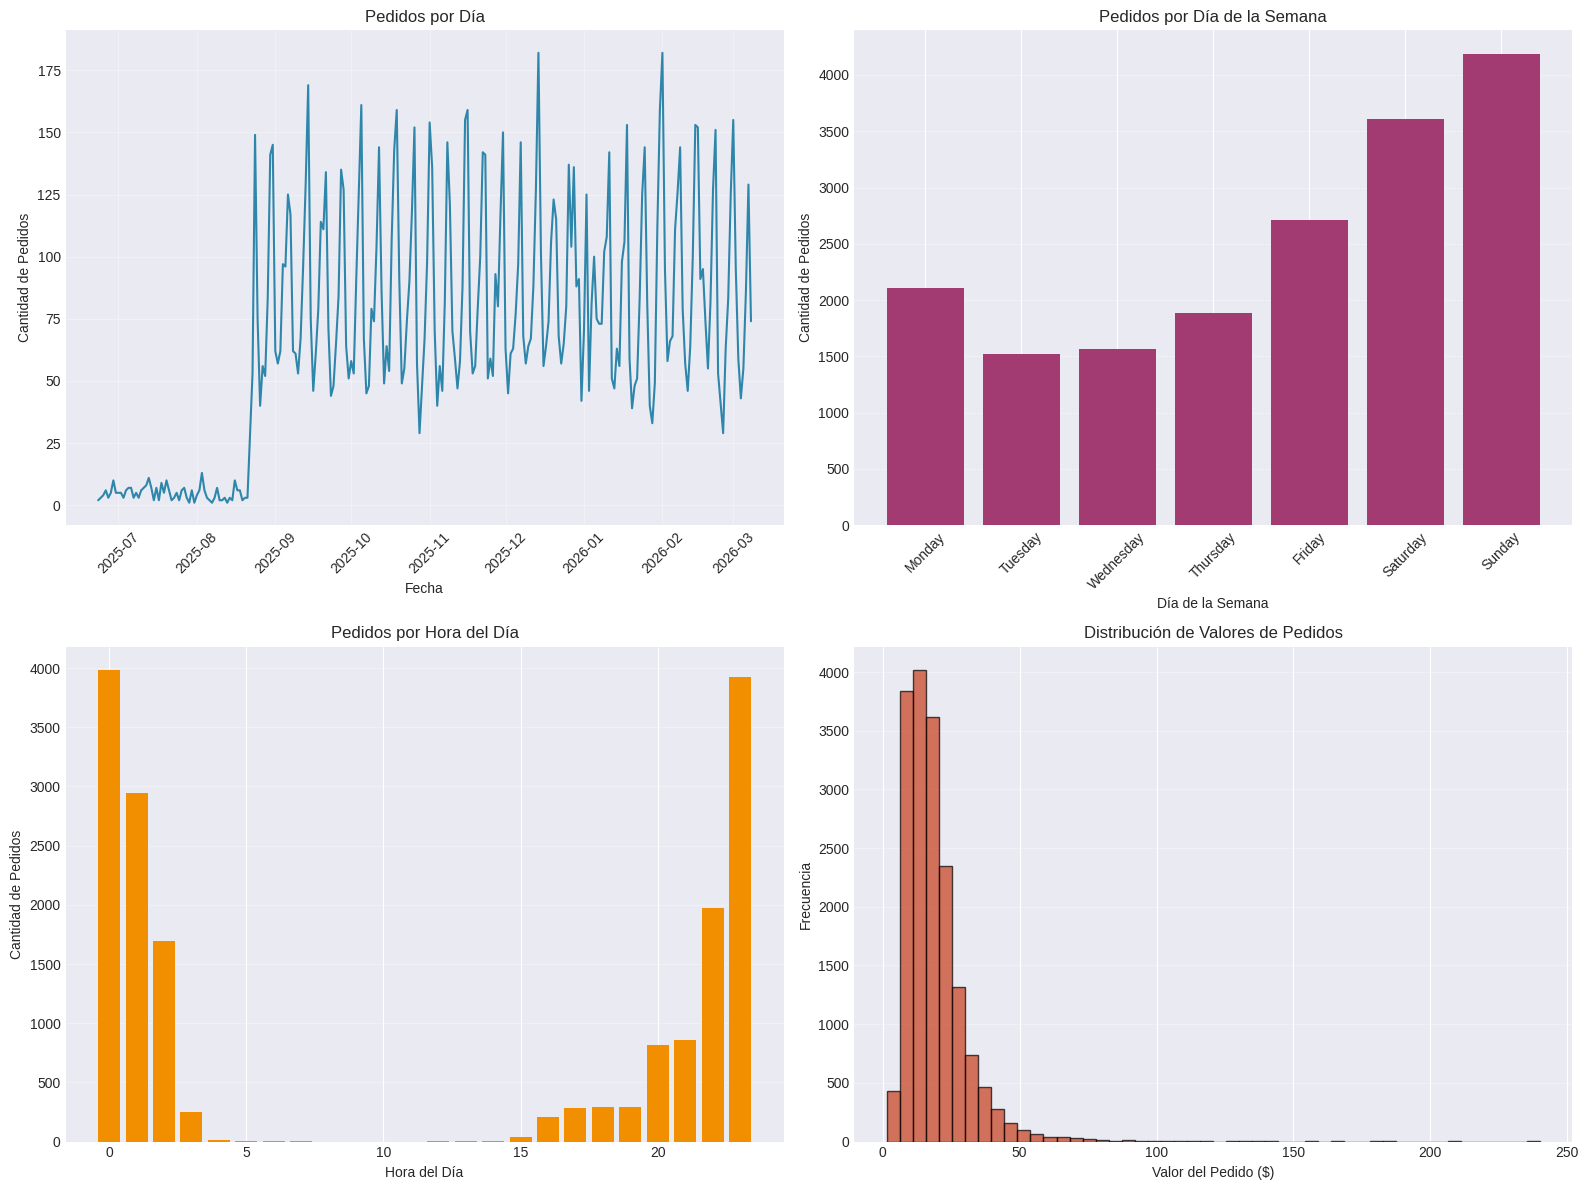

In [ ]:
# Visualización de la distribución temporal de pedidos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Pedidos por día
daily_orders = orders_df.groupby('order_date').size()
axes[0, 0].plot(daily_orders.index, daily_orders.values, linewidth=1.5, color='#2E86AB')
axes[0, 0].set_title('Pedidos por Día', fontsize=12)
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Cantidad de Pedidos')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Pedidos por día de semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = orders_df['day_of_week'].value_counts().reindex(day_order)
axes[0, 1].bar(range(len(day_counts)), day_counts.values, color='#A23B72')
axes[0, 1].set_title('Pedidos por Día de la Semana', fontsize=12)
axes[0, 1].set_xlabel('Día de la Semana')
axes[0, 1].set_ylabel('Cantidad de Pedidos')
axes[0, 1].set_xticks(range(len(day_counts)))
axes[0, 1].set_xticklabels(day_counts.index, rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Pedidos por hora del día
hour_counts = orders_df['hour_of_day'].value_counts().sort_index()
axes[1, 0].bar(hour_counts.index, hour_counts.values, color='#F18F01', width=0.8)
axes[1, 0].set_title('Pedidos por Hora del Día', fontsize=12)
axes[1, 0].set_xlabel('Hora del Día')
axes[1, 0].set_ylabel('Cantidad de Pedidos')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Distribución de valores de pedidos
axes[1, 1].hist(orders_df['total'], bins=50, color='#C73E1D', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribución de Valores de Pedidos', fontsize=12)
axes[1, 1].set_xlabel('Valor del Pedido ($)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('distribucion_pedidos.png', dpi=300, bbox_inches='tight')
plt.show()


## Limitaciones

- **Festivos:** no vienen en el CSV; en los notebooks siguientes se usa el calendario de Venezuela (`holidays`).
- **Promociones:** no hay marca por fecha; en el pipeline se asume sin promoción salvo que más adelante se infiera lo contrario.
- **Temperatura:** no hay serie meteorológica; se omite o queda vacío.

Fechas en texto: convertir a `datetime`. Revisar nulos (p. ej. email o dirección). Archivos en UTF-8. El histórico cubre aproximadamente de mediados de 2025 a marzo 2026; para modelos conviene partir train/validación/test en el tiempo (por ejemplo hasta diciembre 2025, enero–febrero 2026 y marzo 2026), ajustando según el corte real de tus datos.
